# Customer Analysis

### Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

sales = pd.read_csv("../data/processed/sales_analysis.csv")

sales["order_date"] = pd.to_datetime(sales["order_date"])

sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,unit_cost,discount_pct,gross_amount,discount_amount,net_amount,cost_amount,customer_id,order_date,sales_channel,order_status,product_name,category,subcategory,revenue,profit,profit_margin,revenue_difference
0,900001,500001,20014,1.0,557.20,204.62,10,557.20,55.72,501.48,204.62,14258,2025-05-19,Direct,Delivered,Moisturizer 20014,Beauty,Moisturizer,501.48,296.86,59.20,0.0
1,900002,500001,20004,1.0,10687.99,6945.78,15,10687.99,1603.20,9084.79,6945.78,14258,2025-05-19,Direct,Delivered,Yoga Mat 20004,Sports,Yoga Mat,9084.79,2139.01,23.54,0.0
2,900003,500001,20055,1.0,1146.02,721.90,10,1146.02,114.60,1031.42,721.90,14258,2025-05-19,Direct,Delivered,Shampoo 20055,Beauty,Shampoo,1031.42,309.52,30.01,0.0
3,900004,500001,20014,4.0,557.20,204.62,0,2228.80,0.00,2228.80,818.48,14258,2025-05-19,Direct,Delivered,Moisturizer 20014,Beauty,Moisturizer,2228.80,1410.32,63.28,0.0
4,900005,500002,20029,1.0,4040.78,2378.00,10,4040.78,404.08,3636.70,2378.00,12695,2024-07-10,Paid Search,Delivered,Monitor 20029,Electronics,Monitor,3636.70,1258.70,34.61,0.0


In [3]:
sales.shape

(34356, 22)

In [4]:
sales.columns

Index(['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price',
       'unit_cost', 'discount_pct', 'gross_amount', 'discount_amount',
       'net_amount', 'cost_amount', 'customer_id', 'order_date',
       'sales_channel', 'order_status', 'product_name', 'category',
       'subcategory', 'revenue', 'profit', 'profit_margin',
       'revenue_difference'],
      dtype='str')

### Customer Level Dataset

In [5]:
customer_analysis = (
    sales
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        total_profit=("profit", "sum"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

In [6]:
customer_analysis["aov"] = (
    customer_analysis["total_revenue"] /
    customer_analysis["total_orders"]
).round(2)

In [7]:
customer_analysis["profit_margin"] = (
    customer_analysis["total_profit"] /
    customer_analysis["total_revenue"] * 100
).round(2)

In [8]:
customer_analysis.head(10)

,customer_id,total_orders,total_units,total_revenue,total_profit,first_order_date,last_order_date,aov,profit_margin
0,10001,6,15.0,55291.71,24250.93,2024-04-15,2025-05-31,9215.29,43.86
1,10002,1,2.0,3734.42,1396.48,2024-02-13,2024-02-13,3734.42,37.39
2,10003,4,17.0,107693.45,54634.17,2024-04-15,2025-05-16,26923.36,50.73
3,10004,1,5.0,6847.34,3485.18,2025-03-12,2025-03-12,6847.34,50.90
4,10005,4,14.0,29473.65,12287.28,2024-04-20,2025-08-10,7368.41,41.69
5,10006,6,17.0,148843.37,73005.05,2024-03-22,2025-10-13,24807.23,49.05
6,10007,3,6.0,59399.22,21770.23,2024-09-24,2025-03-13,19799.74,36.65
7,10009,3,6.0,129809.06,42021.74,2024-12-04,2025-06-14,43269.69,32.37
8,10010,2,7.0,16433.66,6346.88,2024-11-12,2025-10-14,8216.83,38.62
9,10011,3,11.0,111918.29,56148.60,2024-09-16,2025-10-09,37306.10,50.17


In [9]:
customer_analysis.shape

(4861, 9)

### New v/s Repeat Customers

#### Segment Customers

In [10]:
customer_analysis["customer_type"] = np.where(
    customer_analysis["total_orders"] == 1,
    "One-time",
    "Repeat"
)

customer_analysis["customer_type"].value_counts()

customer_type
Repeat      4323
One-time     538
Name: count, dtype: int64

In [11]:
customer_type_summary = (
    customer_analysis["customer_type"]
    .value_counts()
    .rename_axis("customer_type")
    .reset_index(name="customers")
)

customer_type_summary["customer_share"] = (
    customer_type_summary["customers"] /
    customer_type_summary["customers"].sum() * 100
).round(2)

customer_type_summary

,customer_type,customers,customer_share
0,Repeat,4323,88.93
1,One-time,538,11.07


#### Revenue from one-time vs repeat customers

In [12]:
customer_type_revenue = (
    customer_analysis
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "count"),
        revenue=("total_revenue", "sum"),
        profit=("total_profit", "sum"),
        orders=("total_orders", "sum")
    )
    .reset_index()
)

customer_type_revenue["revenue_share"] = (
    customer_type_revenue["revenue"] /
    customer_type_revenue["revenue"].sum() * 100
).round(2)

customer_type_revenue["profit_margin"] = (
    customer_type_revenue["profit"] /
    customer_type_revenue["revenue"] * 100
).round(2)

customer_type_revenue

,customer_type,customers,revenue,profit,orders,revenue_share,profit_margin
0,One-time,538,9.894876e+06,4.320045e+06,538,3.35,43.66
1,Repeat,4323,2.855979e+08,1.260034e+08,16902,96.65,44.12


### Customer Value Distribution

In [13]:
customer_analysis[
    [
        "total_orders",
        "total_units",
        "total_revenue",
        "total_profit",
        "aov"
    ]
].describe()

,total_orders,total_units,total_revenue,total_profit,aov
count,4861.000000,4861.000000,4861.000000,4861.000000,4861.000000
mean,3.587739,9.743880,60788.476466,26810.017278,17007.303736
std,1.787579,5.882703,58539.696949,26382.729380,16472.127596
min,1.000000,1.000000,225.260000,54.720000,225.260000
25%,2.000000,5.000000,18546.890000,7990.220000,6549.880000
50%,3.000000,9.000000,43377.370000,18834.750000,12479.590000
75%,5.000000,13.000000,83939.250000,37465.190000,21891.730000
max,13.000000,37.000000,580508.980000,268012.780000,210577.490000


In [14]:
top_customers = (
    customer_analysis
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_customers

,customer_id,total_orders,total_units,total_revenue,total_profit,first_order_date,last_order_date,aov,profit_margin,customer_type
1210,11244,8,23.0,580508.98,268012.78,2024-08-05,2025-10-15,72563.62,46.17,Repeat
3656,13765,8,30.0,577266.56,220501.35,2024-06-19,2025-12-07,72158.32,38.20,Repeat
2337,12405,10,31.0,458407.90,225948.82,2024-01-26,2025-10-12,45840.79,49.29,Repeat
1405,11444,8,26.0,394203.78,157009.46,2024-01-08,2025-08-19,49275.47,39.83,Repeat
1901,11954,6,18.0,390169.10,179538.86,2025-01-03,2025-11-21,65028.18,46.02,Repeat
1887,11940,7,23.0,387548.22,193541.19,2024-06-12,2025-07-29,55364.03,49.94,Repeat
3340,13441,7,27.0,375170.46,190229.64,2024-01-04,2025-12-09,53595.78,50.70,Repeat
2710,12788,10,33.0,372391.36,148649.70,2024-05-01,2025-10-25,37239.14,39.92,Repeat
2286,12352,8,22.0,369601.48,146920.87,2024-01-22,2025-11-12,46200.18,39.75,Repeat
2083,12140,2,11.0,367428.73,192177.16,2024-01-30,2025-04-23,183714.37,52.30,Repeat


In [15]:
top_profit_customers = (
    customer_analysis
    .sort_values("total_profit", ascending=False)
    .head(10)
)

top_profit_customers

,customer_id,total_orders,total_units,total_revenue,total_profit,first_order_date,last_order_date,aov,profit_margin,customer_type
1210,11244,8,23.0,580508.98,268012.78,2024-08-05,2025-10-15,72563.62,46.17,Repeat
2337,12405,10,31.0,458407.90,225948.82,2024-01-26,2025-10-12,45840.79,49.29,Repeat
3656,13765,8,30.0,577266.56,220501.35,2024-06-19,2025-12-07,72158.32,38.20,Repeat
1887,11940,7,23.0,387548.22,193541.19,2024-06-12,2025-07-29,55364.03,49.94,Repeat
2083,12140,2,11.0,367428.73,192177.16,2024-01-30,2025-04-23,183714.37,52.30,Repeat
3340,13441,7,27.0,375170.46,190229.64,2024-01-04,2025-12-09,53595.78,50.70,Repeat
1901,11954,6,18.0,390169.10,179538.86,2025-01-03,2025-11-21,65028.18,46.02,Repeat
3352,13454,8,21.0,331144.14,176808.39,2024-04-02,2025-05-18,41393.02,53.39,Repeat
1215,11249,11,37.0,336310.79,175572.42,2024-03-11,2025-07-23,30573.71,52.21,Repeat
2518,12591,8,23.0,317347.39,163476.38,2024-01-11,2025-11-27,39668.42,51.51,Repeat


#### Customer revenue distribution

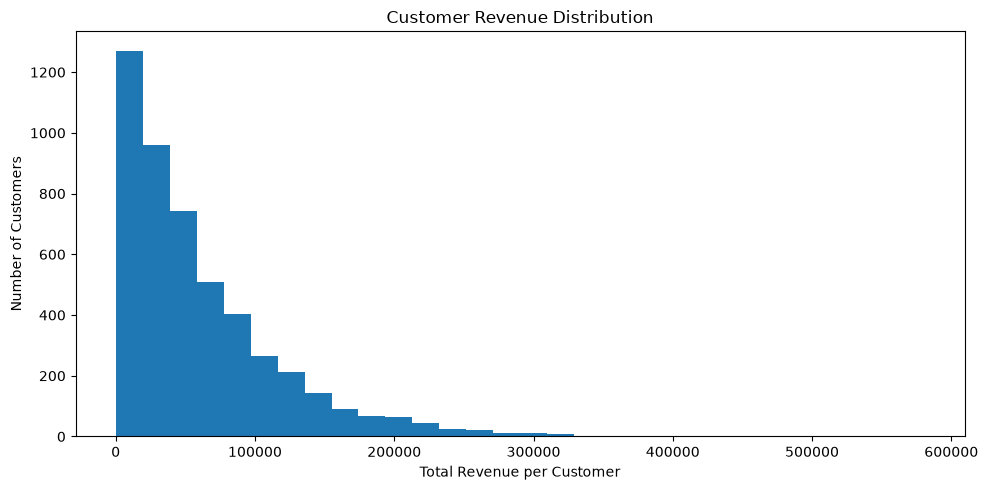

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_analysis["total_revenue"],
    bins=30
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Total Revenue per Customer")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### RFM Analysis

In [17]:
## Analysis date 

analysis_date = sales["order_date"].max() + pd.Timedelta(days=1)

analysis_date

Timestamp('2026-01-01 00:00:00')

In [18]:
# calclate rfm values

rfm = (
    sales
    .groupby("customer_id")
    .agg(
        last_purchase=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("revenue", "sum")
    )
    .reset_index()
)

rfm["recency"] = (
    analysis_date - rfm["last_purchase"]
).dt.days

rfm = rfm[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary"
    ]
]

rfm.head()

,customer_id,recency,frequency,monetary
0,10001,215,6,55291.71
1,10002,688,1,3734.42
2,10003,230,4,107693.45
3,10004,295,1,6847.34
4,10005,144,4,29473.65


### Create RFM Score

In [19]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [20]:
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [21]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [22]:
### Combine the scores

rfm["RFM_score"] = (
    rfm["R_score"].astype(int).astype(str) +
    rfm["F_score"].astype(int).astype(str) +
    rfm["M_score"].astype(int).astype(str)
)

rfm.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,10001,215,6,55291.71,2,5,3,253
1,10002,688,1,3734.42,1,1,1,111
2,10003,230,4,107693.45,2,3,5,235
3,10004,295,1,6847.34,2,1,1,211
4,10005,144,4,29473.65,3,3,2,332
5,10006,80,6,148843.37,4,5,5,455
6,10007,294,3,59399.22,2,2,4,224
7,10009,201,3,129809.06,2,2,5,225
8,10010,79,2,16433.66,4,1,2,412
9,10011,84,3,111918.29,4,2,5,425


### Create Business Segments

In [23]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    
    elif row["R_score"] >= 4 and row["F_score"] >= 3:
        return "Loyal Customers"
    
    elif row["R_score"] >= 4 and row["F_score"] <= 2:
        return "New Customers"
    
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost Customers"
    
    else:
        return "Potential Loyalists"

rfm["segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [24]:
segment_summary = (
    rfm["segment"]
    .value_counts()
    .rename_axis("segment")
    .reset_index(name="customers")
)

segment_summary["customer_share"] = (
    segment_summary["customers"] /
    segment_summary["customers"].sum() * 100
).round(2)

segment_summary

,segment,customers,customer_share
0,Lost Customers,1110,22.83
1,Potential Loyalists,963,19.81
2,At Risk,834,17.16
3,Loyal Customers,753,15.49
4,Champions,704,14.48
5,New Customers,497,10.22


### Segment Revenue

In [25]:
segment_value = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        revenue=("monetary", "sum"),
        avg_customer_value=("monetary", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_recency=("recency", "mean")
    )
    .reset_index()
)

segment_value["revenue_share"] = (
    segment_value["revenue"] /
    segment_value["revenue"].sum() * 100
).round(2)

segment_value.sort_values(
    "revenue",
    ascending=False
)

,segment,customers,revenue,avg_customer_value,avg_frequency,avg_recency,revenue_share
1,Champions,704,88346919.91,125492.783963,5.846591,47.758523,29.90
5,Potential Loyalists,963,60459336.39,62782.280779,3.736241,144.463136,20.46
0,At Risk,834,57357037.91,68773.426751,4.103118,297.985612,19.41
3,Loyal Customers,753,35994214.67,47801.081899,4.249668,50.019920,12.18
2,Lost Customers,1110,34248552.98,30854.552234,1.807207,393.663063,11.59
4,New Customers,497,19086722.24,38403.867686,2.209256,52.782696,6.46


### Customer Activity & Inactivity

In [26]:
rfm["recency"].describe()

count    4861.000000
mean      189.698416
std       163.512368
min         1.000000
25%        61.000000
50%       143.000000
75%       276.000000
max       731.000000
Name: recency, dtype: float64

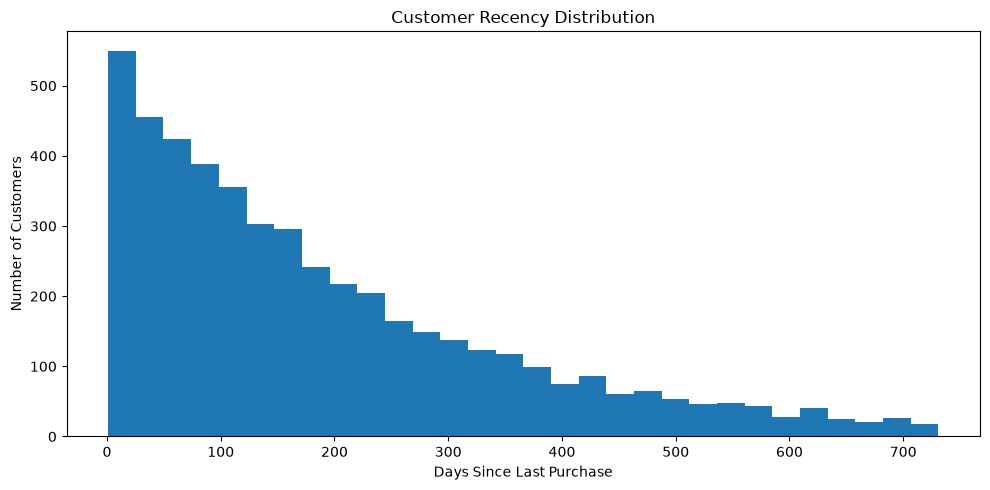

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(
    rfm["recency"],
    bins=30
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [29]:
### Create activity groups

def activity_status(recency):
    if recency <= 90:
        return "Active"
    elif recency <= 180:
        return "At Risk"
    else:
        return "Inactive"

rfm["activity_status"] = rfm["recency"].apply(activity_status)

In [30]:
activity_summary = (
    rfm["activity_status"]
    .value_counts()
    .rename_axis("activity_status")
    .reset_index(name="customers")
)

activity_summary["customer_share"] = (
    activity_summary["customers"] /
    activity_summary["customers"].sum() * 100
).round(2)

activity_summary

,activity_status,customers,customer_share
0,Inactive,1996,41.06
1,Active,1693,34.83
2,At Risk,1172,24.11


### Combine Customer + RFM Data

In [31]:
customer_final = customer_analysis.merge(
    rfm[
        [
            "customer_id",
            "recency",
            "R_score",
            "F_score",
            "M_score",
            "RFM_score",
            "segment",
            "activity_status"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_final.head()

,customer_id,total_orders,total_units,total_revenue,total_profit,first_order_date,last_order_date,aov,profit_margin,customer_type,recency,R_score,F_score,M_score,RFM_score,segment,activity_status
0,10001,6,15.0,55291.71,24250.93,2024-04-15,2025-05-31,9215.29,43.86,Repeat,215,2,5,3,253,At Risk,Inactive
1,10002,1,2.0,3734.42,1396.48,2024-02-13,2024-02-13,3734.42,37.39,One-time,688,1,1,1,111,Lost Customers,Inactive
2,10003,4,17.0,107693.45,54634.17,2024-04-15,2025-05-16,26923.36,50.73,Repeat,230,2,3,5,235,At Risk,Inactive
3,10004,1,5.0,6847.34,3485.18,2025-03-12,2025-03-12,6847.34,50.90,One-time,295,2,1,1,211,Lost Customers,Inactive
4,10005,4,14.0,29473.65,12287.28,2024-04-20,2025-08-10,7368.41,41.69,Repeat,144,3,3,2,332,Potential Loyalists,At Risk


In [32]:
customer_final.shape

(4861, 17)

In [33]:
customer_final.isna().sum()

customer_id         0
total_orders        0
total_units         0
total_revenue       0
total_profit        0
first_order_date    0
last_order_date     0
aov                 0
profit_margin       0
customer_type       0
recency             0
R_score             0
F_score             0
M_score             0
RFM_score           0
segment             0
activity_status     0
dtype: int64

In [34]:
customer_final.to_csv(
    "../data/processed/customer_analysis.csv",
    index=False
)

print(
    "customer_analysis.csv saved:",
    customer_final.shape
)

customer_analysis.csv saved: (4861, 17)


### Final Customer Insights

In [35]:
# Highest Value Customers

customer_final[
    [
        "customer_id",
        "total_orders",
        "total_revenue",
        "total_profit",
        "RFM_score",
        "segment"
    ]
].sort_values(
    "total_revenue",
    ascending=False
).head(10)

,customer_id,total_orders,total_revenue,total_profit,RFM_score,segment
1210,11244,8,580508.98,268012.78,455,Champions
3656,13765,8,577266.56,220501.35,555,Champions
2337,12405,10,458407.90,225948.82,455,Champions
1405,11444,8,394203.78,157009.46,355,Potential Loyalists
1901,11954,6,390169.10,179538.86,555,Champions
1887,11940,7,387548.22,193541.19,355,Potential Loyalists
3340,13441,7,375170.46,190229.64,555,Champions
2710,12788,10,372391.36,148649.70,455,Champions
2286,12352,8,369601.48,146920.87,455,Champions
2083,12140,2,367428.73,192177.16,215,Lost Customers


In [36]:
# Customers at risk

customer_final[
    customer_final["activity_status"] == "At Risk"
].sort_values(
    "total_revenue",
    ascending=False
).head(10)

,customer_id,total_orders,total_units,total_revenue,total_profit,first_order_date,last_order_date,aov,profit_margin,customer_type,recency,R_score,F_score,M_score,RFM_score,segment,activity_status
1405,11444,8,26.0,394203.78,157009.46,2024-01-08,2025-08-19,49275.47,39.83,Repeat,135,3,5,5,355,Potential Loyalists,At Risk
1887,11940,7,23.0,387548.22,193541.19,2024-06-12,2025-07-29,55364.03,49.94,Repeat,156,3,5,5,355,Potential Loyalists,At Risk
1215,11249,11,37.0,336310.79,175572.42,2024-03-11,2025-07-23,30573.71,52.21,Repeat,162,3,5,5,355,Potential Loyalists,At Risk
4340,14471,8,27.0,328764.67,132127.22,2024-01-02,2025-08-06,41095.58,40.19,Repeat,148,3,5,5,355,Potential Loyalists,At Risk
3829,13942,5,13.0,318852.55,129961.00,2024-03-16,2025-08-28,63770.51,40.76,Repeat,126,3,5,5,355,Potential Loyalists,At Risk
203,10206,9,30.0,308028.09,131599.70,2024-03-21,2025-09-26,34225.34,42.72,Repeat,97,4,5,5,455,Champions,At Risk
2412,12481,7,14.0,303073.27,153224.61,2024-04-22,2025-08-18,43296.18,50.56,Repeat,136,3,5,5,355,Potential Loyalists,At Risk
4577,14710,4,21.0,301953.36,145615.54,2024-07-25,2025-07-31,75488.34,48.22,Repeat,154,3,4,5,345,Potential Loyalists,At Risk
3349,13451,5,17.0,280677.56,100288.10,2024-06-16,2025-08-11,56135.51,35.73,Repeat,143,3,5,5,355,Potential Loyalists,At Risk
1581,11623,6,17.0,277112.63,123339.80,2024-07-07,2025-08-18,46185.44,44.51,Repeat,136,3,5,5,355,Potential Loyalists,At Risk


In [37]:
# Inactive customers with high historical value

customer_final[
    customer_final["activity_status"] == "Inactive"
].sort_values(
    "total_revenue",
    ascending=False
).head(10)

,customer_id,total_orders,total_units,total_revenue,total_profit,first_order_date,last_order_date,aov,profit_margin,customer_type,recency,R_score,F_score,M_score,RFM_score,segment,activity_status
2083,12140,2,11.0,367428.73,192177.16,2024-01-30,2025-04-23,183714.37,52.30,Repeat,253,2,1,5,215,Lost Customers,Inactive
3352,13454,8,21.0,331144.14,176808.39,2024-04-02,2025-05-18,41393.02,53.39,Repeat,228,2,5,5,255,At Risk,Inactive
4799,14937,4,17.0,314888.26,98898.12,2024-06-09,2025-04-15,78722.06,31.41,Repeat,261,2,4,5,245,At Risk,Inactive
2766,12846,5,17.0,291189.24,114249.21,2024-02-02,2024-05-13,58237.85,39.24,Repeat,598,1,4,5,145,At Risk,Inactive
2219,12282,5,14.0,288383.94,144633.80,2024-06-23,2025-02-08,57676.79,50.15,Repeat,327,1,4,5,145,At Risk,Inactive
4648,14783,5,22.0,281089.33,112439.26,2024-01-13,2025-05-26,56217.87,40.00,Repeat,220,2,5,5,255,At Risk,Inactive
3320,13420,6,20.0,279748.22,147350.95,2024-01-14,2025-06-17,46624.70,52.67,Repeat,198,2,5,5,255,At Risk,Inactive
3088,13178,6,13.0,277055.50,110791.88,2024-01-09,2025-01-01,46175.92,39.99,Repeat,365,1,5,5,155,At Risk,Inactive
2916,13002,3,7.0,274775.84,131352.49,2024-04-06,2024-08-25,91591.95,47.80,Repeat,494,1,3,5,135,At Risk,Inactive
2904,12990,5,13.0,267601.02,103134.28,2024-04-30,2025-02-11,53520.20,38.54,Repeat,324,1,5,5,155,At Risk,Inactive
